# 1. Set up

In [1]:
!pip install pandas
!pip install scikit-learn
!pip install pyarrow
!pip install torch
!pip install xgboost category_encoders scikit-plot
!pip install pyproj
!pip install seaborn

# 2. Import necessary libraries

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.calibration import CalibratedClassifierCV

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
import category_encoders as ce
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_auc_score, roc_curve,confusion_matrix, classification_report, precision_recall_curve, auc, recall_score, precision_score,
    f1_score, accuracy_score
)
from pyproj import Transformer
from tqdm import tqdm
import xgboost as xgb

from utils import *

import shap

c:\Users\alarrinoar\Desktop\Projects\UFD\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 3. Define global variables

we will be using march as the training month and april as the validation month

In [3]:
pd.options.display.max_columns = 999

In [4]:
INPUT_X_PATH = "../data/output_data/data_training_may.csv"
INPUT_X_EVAL_PATH = "../data/output_data/data_validation_june.csv"
INPUT_Y_PATH = "../data/output_data/data_training_may_y.csv"
INPUT_Y_EVAL_PATH = "../data/output_data/data_validation_june_y.csv"

INPUT_FINAL_DF_PATH = "../data/output_data/final_df_non_supervised_may.csv"
INPUT_FINAL_DF_EVAL_PATH = "../data/output_data/final_df_eval_non_supervised_june.csv"

In [5]:
target_col = "target"

Let's define some colors for the viz we will be doing

In [6]:
ufd_orange = "#f26122"
ufd_blue = "#003865"
ufd_gray = "#cccccc"

In [7]:
cols = ["cups_sgc", "cnt_id", "consumo_zero_anio_actual", "consumo_zero_anio_anterior", 
"porcentaje_calidad_datos_trimestre_pasado_correctos", "porcentaje_calidad_datos_anio_actual_correctos", "porcentaje_calidad_datos_anio_actual_incorrectos", 
"consumo_count_anio_anterior"]

# 4. Functions

In [8]:
class FullyConnectedNN(nn.Module):
    def __init__(self, input_dim):
        super(FullyConnectedNN, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1),
            nn.Sigmoid()  # output between 0 and 1
        )

    def forward(self, x):
        return self.network(x)

# 5. Code

## 5.1. Data loading

We will load the data, both the training and the validation data

In [9]:
X = pd.read_csv(INPUT_X_PATH, sep=";")
y = pd.read_csv(INPUT_Y_PATH, sep=";")[target_col]
X_eval = pd.read_csv(INPUT_X_EVAL_PATH, sep=";")
y_eval = pd.read_csv(INPUT_Y_EVAL_PATH, sep=";")[target_col]

final_df = pd.read_csv(INPUT_FINAL_DF_PATH, sep=";")
final_df_eval = pd.read_csv(INPUT_FINAL_DF_EVAL_PATH, sep=";")

In [10]:
X.head(5)

,porcentaje_calidad_datos_trimestre_pasado_correctos,cnt_inspecciones_anio_pasado,cnt_inspecciones_anio_actual,consumo_count_anio_actual,porcentaje_calidad_datos_trimestre_actual_correctos,cnt_inspecciones_trimestre_pasado,porcentaje_calidad_datos_mes_pasado_correctos,porcentaje_calidad_datos_anio_actual_correctos,cnt_inspecciones_mismo_trimestre_anio_pasado,cnt_inspecciones_trimestre_actual,cnt_inspecciones_mes_actual,porcentaje_calidad_datos_trimestre_actual_incorrectos,consumo_count_anio_anterior,porcentaje_calidad_datos_mes_pasado_incorrectos,consumo_zero_mes_pasado,consumo_max_mes_actual,porcentaje_calidad_datos_anio_anterior_correctos,consumo_max_anio_actual,consumo_zero_trimestre_actual,cnt_inspecciones_semana_pasada,consumo_max_trimestre_actual,cnt_inspecciones_mismo_mes_anio_pasado,cnt_inspecciones_semana_actual,cnt_inspecciones_mes_pasado,cnt_eventos_anio_pasado_4_12,consumo_max_trimestre_pasado,consumo_max_mes_anio_pasado,porcentaje_calidad_datos_anio_actual_incorrectos,consumo_max_semana_actual,consumo_zero_trimestre_pasado,consumo_max_mes_pasado,cnt_eventos_anio_pasado_4_11,consumo_max_anio_anterior,consumo_stddev_anio_actual,consumo_suma_anio_actual,consumo_max_semana_pasada,cnt_inspecciones_misma_semana_anio_pasado,consumo_media_semana_pasada,coef_variacion_trimestre_actual,consumo_umbral_trimestre_pasado,consumo_umbral_mes_pasado,consumo_max_trimestre_anio_pasado,consumo_stddev_semana_actual,coef_variacion_semana_actual,cnt_eventos_trimestre_pasado_6_NA,consumo_max_semana_anio_pasado,consumo_media_semana_actual,consumo_media_anio_actual,cnt_eventos_mismo_trimestre_anio_pasado_4_11,cnt_eventos_anio_actual_6_NA,cnt_eventos_anio_actual_4_11,consumo_min_semana_actual,consumo_min_semana_pasada,porcentaje_calidad_datos_mes_actual_correctos,consumo_media_mes_actual,consumo_stddev_anio_anterior,consumo_umbral_trimestre_actual,cnt_eventos_mismo_trimestre_anio_pasado_2_5,consumo_min_mes_actual,consumo_stddev_semana_pasada,consumo_suma_trimestre_anio_pasado,consumo_stddev_trimestre_actual,cnt_eventos_mismo_mes_anio_pasado_4_11,consumo_stddev_trimestre_pasado,consumo_umbral_anio_actual,consumo_stddev_trimestre_anio_pasado,porcentaje_calidad_datos_mismo_trimestre_anio_pasado_correctos,cnt_eventos_anio_actual_4_12,consumo_stddev_mes_pasado,cnt_eventos_anio_pasado_6_NA,cnt_eventos_mismo_mes_anio_pasado_6_NA,cnt_eventos_mismo_trimestre_anio_pasado_4_12,cnt_eventos_anio_actual_1_21,coef_variacion_mes_actual,pct_change_trimestre_actual_vs_pasado,consumo_suma_mes_actual,cnt_eventos_trimestre_actual_6_NA,consumo_media_trimestre_pasado,consumo_stddev_semana_anio_pasado,consumo_umbral_anio_anterior,cnt_eventos_trimestre_pasado_4_11,cnt_eventos_mes_pasado_1_9,consumo_media_mes_anio_pasado,consumo_stddev_mes_anio_pasado,consumo_umbral_semana_actual,cnt_eventos_trimestre_actual_1_3,consumo_media_trimestre_anio_pasado,consumo_suma_trimestre_pasado,cnt_eventos_trimestre_pasado_1_21,cnt_eventos_mismo_trimestre_anio_pasado_2_4,cnt_eventos_mes_actual_6_NA,consumo_stddev_mes_actual,consumo_suma_semana_pasada,consumo_media_trimestre_actual,consumo_suma_trimestre_actual,consumo_suma_mes_pasado,consumo_zero_anio_actual,cnt_eventos_trimestre_pasado_1_3,cnt_eventos_anio_actual_3_22,pct_change_anio_actual_vs_anterior,cnt_eventos_trimestre_pasado_1_9,cnt_eventos_mismo_trimestre_anio_pasado_6_NA,consumo_umbral_semana_pasada,consumo_media_semana_anio_pasado,consumo_umbral_trimestre_anio_pasado,consumo_suma_semana_actual,cnt_eventos_anio_actual_1_3,cnt_eventos_mes_pasado_6_NA,cnt_eventos_trimestre_actual_1_21,consumo_umbral_mes_actual,consumo_media_anio_anterior,cnt_eventos_semana_actual_6_NA,consumo_suma_mes_anio_pasado,pct_change_trimestre_actual_vs_anio_pasado,cnt_eventos_trimestre_actual_1_2,consumo_zero_trimestre_anio_pasado,cnt_eventos_anio_actual_4_7,consumo_zero_anio_anterior,cnt_eventos_mes_pasado_3_22,consumo_zero_mes_anio_pasado,consumo_zero_mes_actual,consumo_umbral_mes_anio_pasado,cnt_eventos_anio_pasado_1_2,consumo_min_mes_anio_pasado,cn

In [11]:
final_df["cnt_id"].nunique()

69994

In [12]:
final_df["cups_sgc"].nunique()

69994

In [13]:
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
cat_cols = [col for col in cat_cols if col not in ['cups_sgc', 'cnt_id', target_col]]

## 5.2. Supervised learning

In [14]:
X.fillna(0, inplace=True)
y.fillna(0, inplace=True)

X_eval.fillna(0, inplace=True)
y_eval.fillna(0, inplace=True)

### 5.2.1. Modelling

In case we have some categorical data, we'll apply the target encoding

In [15]:
encoder = ce.TargetEncoder(cols=cat_cols)
X_train_enc = encoder.fit_transform(X, y)
X_val_enc = encoder.transform(X_eval)

We need to scale the data, we will scale it between -1 and 1 in order to make a faster training in the neural network

In [16]:
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_enc), columns=X.columns)
X_val_scaled = pd.DataFrame(scaler.transform(X_val_enc), columns=X_eval.columns)

We select the device we are using

In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [18]:
X_train_tensor = torch.tensor(X_train_scaled.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y.values, dtype=torch.float32)

X_val_tensor = torch.tensor(X_val_scaled.values, dtype=torch.float32)
y_val_tensor = torch.tensor(y_eval.values, dtype=torch.float32)

we convert the data into pytorch datasets:

In [19]:
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

And we create the data loader

In [20]:
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=512, shuffle=False)

We need to call the fullyconnected class defined before

In [21]:
input_dim = X_train_scaled.shape[1]

In [22]:
model = FullyConnectedNN(input_dim=input_dim)

We define the loss function and the oprimizer we are using:

In [23]:
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

And we train end evaluate the model

In [24]:
model = model.to(device)

for epoch in range(30):
    model.train()
    actual_loss = 0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device).view(-1, 1)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward() # backpropagation
        optimizer.step() # parameters updating
        
        actual_loss += loss.item()
        
    model.eval()
    y_train_true, y_train_pred = [], []
    y_val_true, y_val_pred = [], []

    with torch.no_grad():
        # --- Train ---
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            preds = model(X_batch).cpu().numpy()
            y_train_true.extend(y_batch.numpy())
            y_train_pred.extend(preds)

        # --- Validation ---
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            preds = model(X_batch).cpu().numpy()
            y_val_true.extend(y_batch.numpy())
            y_val_pred.extend(preds)

    # Convert into numpy arrays
    y_train_true, y_train_pred = np.array(y_train_true), np.array(y_train_pred)
    y_val_true, y_val_pred = np.array(y_val_true), np.array(y_val_pred)

    # We find the optimal threshold in the training set
    threshold_opt, _ = find_optimal_thres(y_train_true, y_train_pred, objetivo="f1", plot=False)

    # Apply the threshold in the validation set
    y_val_pred_bin = (y_val_pred >= threshold_opt).astype(int)

    # Get the metrics per epoch
    auc = roc_auc_score(y_val_true, y_val_pred)
    pre = precision_score(y_val_true, y_val_pred_bin)
    rec = recall_score(y_val_true, y_val_pred_bin)
    f1 = f1_score(y_val_true, y_val_pred_bin)
    print(f"Epoch [{epoch+1}/{30}] | Loss: {actual_loss/len(train_loader):.4f} | AUC: {auc:.4f} | Precision: {pre:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}")

Epoch [1/30] | Loss: 0.0953 | AUC: 0.9212 | Precision: 0.2859 | Recall: 0.4158 | F1: 0.3388
Epoch [2/30] | Loss: 0.0401 | AUC: 0.9317 | Precision: 0.2772 | Recall: 0.4807 | F1: 0.3516
Epoch [3/30] | Loss: 0.0385 | AUC: 0.9386 | Precision: 0.2926 | Recall: 0.4853 | F1: 0.3651
Epoch [4/30] | Loss: 0.0360 | AUC: 0.9463 | Precision: 0.2988 | Recall: 0.4946 | F1: 0.3725
Epoch [5/30] | Loss: 0.0350 | AUC: 0.9579 | Precision: 0.2953 | Recall: 0.5193 | F1: 0.3765
Epoch [6/30] | Loss: 0.0344 | AUC: 0.9581 | Precision: 0.2932 | Recall: 0.5641 | F1: 0.3858
Epoch [7/30] | Loss: 0.0326 | AUC: 0.9577 | Precision: 0.3385 | Recall: 0.5379 | F1: 0.4155
Epoch [8/30] | Loss: 0.0307 | AUC: 0.9709 | Precision: 0.3494 | Recall: 0.5595 | F1: 0.4302
Epoch [9/30] | Loss: 0.0300 | AUC: 0.9755 | Precision: 0.3636 | Recall: 0.5997 | F1: 0.4527
Epoch [10/30] | Loss: 0.0292 | AUC: 0.9777 | Precision: 0.4091 | Recall: 0.5703 | F1: 0.4764
Epoch [11/30] | Loss: 0.0287 | AUC: 0.9782 | Precision: 0.4399 | Recall: 0.5487

### 5.2.2. Metrics extraction

Para poder calcular las métricas, en primer lugar debemos calcular las predicciones

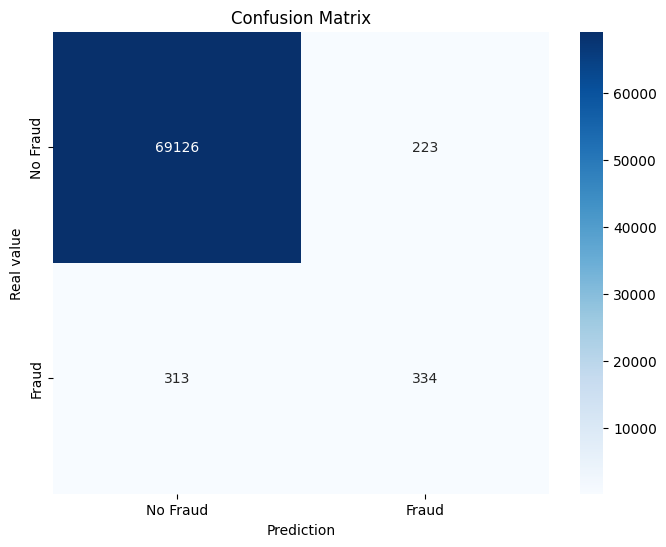


Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     69349
         1.0       0.60      0.52      0.55       647

    accuracy                           0.99     69996
   macro avg       0.80      0.76      0.78     69996
weighted avg       0.99      0.99      0.99     69996



In [25]:
cm = confusion_matrix(y_val_true, y_val_pred_bin)
# Crear una visualización más clara
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Fraud', 'Fraud'],
            yticklabels=['No Fraud', 'Fraud'])
plt.title('Confusion Matrix')
plt.xlabel('Prediction')
plt.ylabel('Real value')
plt.show()
 
print("\nClassification Report:")
print(classification_report(y_val_true, y_val_pred_bin))

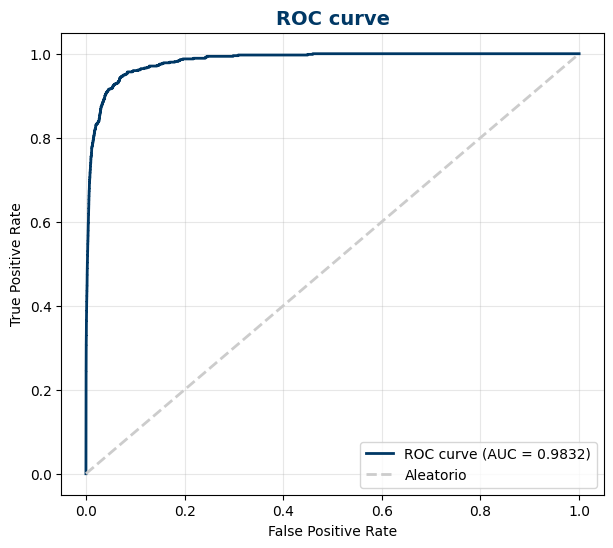

ROC AUC Score: 0.9832


In [26]:
fpr, tpr, thresholds = roc_curve(y_val_true, y_val_pred)
roc_auc = roc_auc_score(y_val_true, y_val_pred)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, color=ufd_blue, lw=2, label=f"ROC curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], color=ufd_gray, lw=2, linestyle="--", label="Aleatorio")

# Estilo
plt.grid(alpha=0.3)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve", fontsize=14, weight="bold", color=ufd_blue)
plt.legend(loc="lower right", fontsize=10)
plt.show()

print(f"ROC AUC Score: {roc_auc:.4f}")

Let's see also gain and lift curves

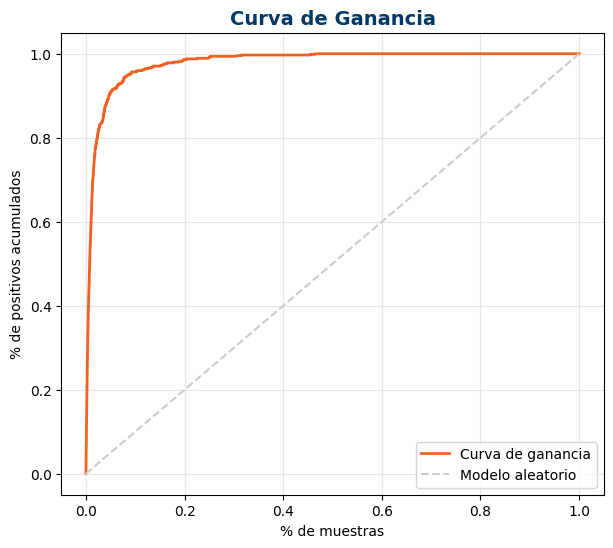

In [27]:
plot_gain(y_val_true, y_val_pred)

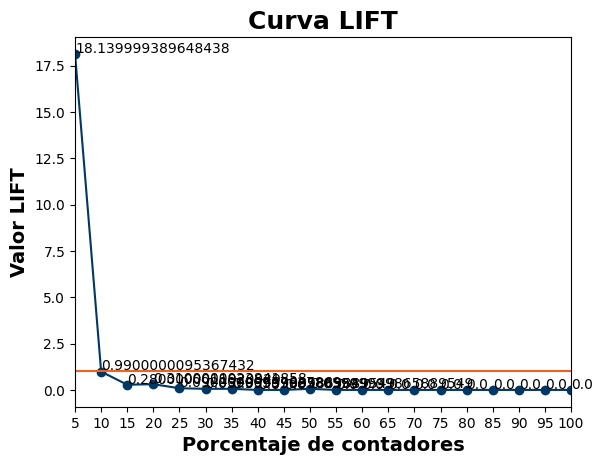

In [28]:
lift_chart_plot(y_val_true, y_val_pred, num_chunks=20)

In [29]:
final_df["target"].value_counts()

target
0.0    69272
1.0      722
Name: count, dtype: int64

In [30]:
final_df["pred_proba"] = y_proba

NameError: name 'y_proba' is not defined

In [ ]:
final_df["final_scoring"] = final_df["fraude_score_no_supervisado"]*0.3 + final_df["pred_proba"]*0.7

We define the cuts attending to the lift chart previously defined:

In [ ]:
cuts = [25, 35]  
thresholds = get_probability_thresholds(y, y_proba, cuts)

print("Thresholds:", thresholds)

Thresholds: [1.435371586921974e-06, 6.487098858087847e-07]


We create the new cateogria_fraude column used to order the probabilistic results of the fraud

In [ ]:
conditions = [
    final_df["final_scoring"] < thresholds[0],                             
    (final_df["final_scoring"] >= thresholds[0]) & (final_df["final_scoring"] < thresholds[1]),  
    final_df["final_scoring"] >= thresholds[1]                             
]

choices = ["Bajo", "Medio", "Alto"]

final_df["categoria_fraude"] = np.select(conditions, choices, default="Bajo")